# 10 — Noise Model Calibration: Exact Gain g and Read Noise σ

**QUESTION:** What is the exact gain g and read noise σ for each stack?
What augmentation range do I need?

**MODEL:** variance = g × mean + σ²
- g = gain (slope, photons per ADU)
- σ = read noise std (intercept)

**RESULT:** Exact parameters for NLL loss + augmentation range

In [1]:
from pathlib import Path
from load_data import load_all_stacks

stacks = load_all_stacks()

Loaded F0: (1500, 490, 490)
Loaded F1: (1500, 490, 490)
Loaded F2: (1500, 490, 490)
Loaded F3: (1500, 490, 490)


In [2]:
from calibration import calibrate_all_stacks

calibration_results = calibrate_all_stacks(stacks)


Calibrating F0
Background pixels: 24010 / 240100

Fit results:
  Gain g = -0.109260
  Read noise σ = 14.393723
  Intercept σ² = 207.179258
  R² = 0.2373
  ⚠ Poor fit → Mixed noise model, reconsider NLL

Calibrating F1
Background pixels: 24010 / 240100

Fit results:
  Gain g = 0.002828
  Read noise σ = 11.388999
  Intercept σ² = 129.709302
  R² = 0.0014
  ⚠ Poor fit → Mixed noise model, reconsider NLL

Calibrating F2
Background pixels: 24010 / 240100

Fit results:
  Gain g = 0.181858
  Read noise σ = 23.558051
  Intercept σ² = 554.981780
  R² = 0.1251
  ⚠ Poor fit → Mixed noise model, reconsider NLL

Calibrating F3
Background pixels: 24010 / 240100

Fit results:
  Gain g = 0.100397
  Read noise σ = 24.797909
  Intercept σ² = 614.936274
  R² = 0.0299
  ⚠ Poor fit → Mixed noise model, reconsider NLL


In [3]:
from analysis import print_summary

print_summary(calibration_results)


NOISE MODEL CALIBRATION SUMMARY

| Stack | Gain g    | Read Noise σ | σ² (intercept) | R²    | Poisson? |
|-------|-----------|--------------|----------------|-------|----------|
| F0     | -0.109260 |    14.393723 |     207.179258 | 0.237 | ✗        |
| F1     |  0.002828 |    11.388999 |     129.709302 | 0.001 | ✗        |
| F2     |  0.181858 |    23.558051 |     554.981780 | 0.125 | ✗        |
| F3     |  0.100397 |    24.797909 |     614.936274 | 0.030 | ✗        |



✓ Calibration plot saved to /tmp/noise_model_calibration.png


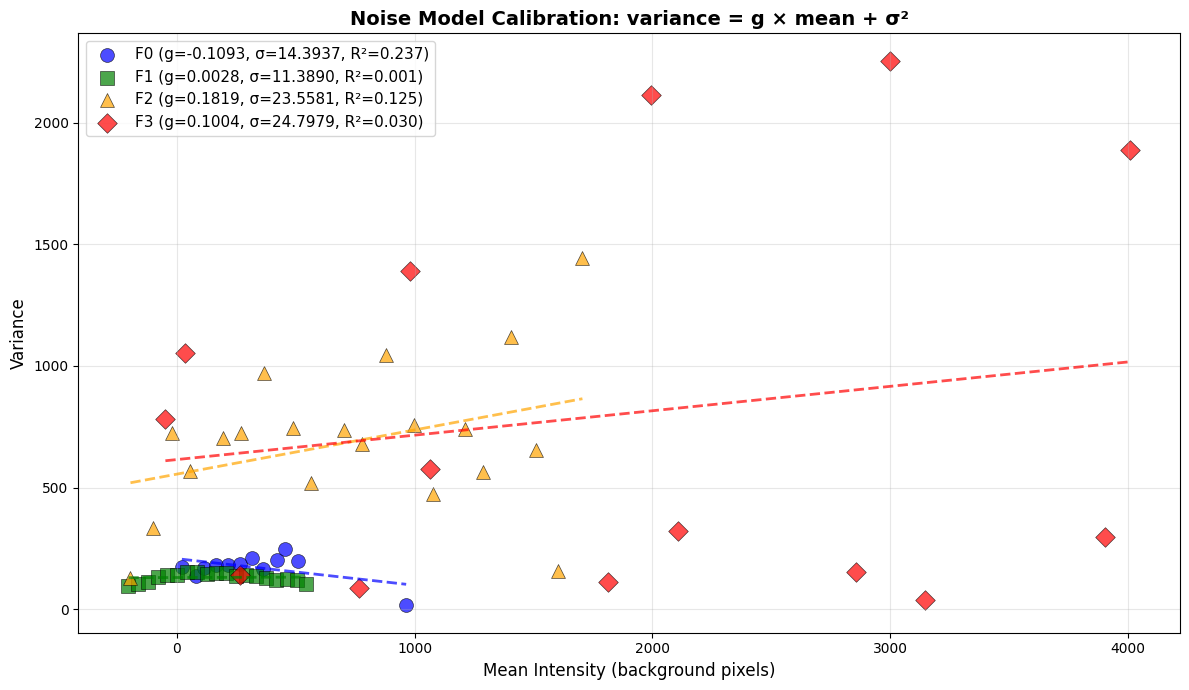

In [4]:
from plots import plot_calibration

plot_calibration(calibration_results, save_path='/tmp/noise_model_calibration.png')

In [5]:
from analysis import get_augmentation_range

aug_range = get_augmentation_range(calibration_results)


AUGMENTATION RANGE

Gain range across stacks:
  Min gain (g_min): -0.109260
  Max gain (g_max): 0.181858
  Ratio: -1.66×

Augmentation range (with 3× safety margin):
  g_aug_min = -0.109260 / 3 = -0.036420
  g_aug_max = 0.181858 × 3 = 0.545574
  Augmentation range: [-0.036420, 0.545574]

Why 3× safety margin?
  - 1× covers observed data (F0-F3)
  - 3× covers potential Task 2 OOD gain
  - If Task 2 test gain outside [g_aug_min, g_aug_max]
    → you lose 5+ dB on Task 2



In [6]:
from analysis import print_nll_guidance

print_nll_guidance(calibration_results, aug_range)


USE IN NLL LOSS

For each stack, use fitted parameters in Poisson-Gaussian NLL:

NLL = -log p(y | x, g, σ)
    = -log N(y | x, σ²) - log Poisson(binom | g*x)

Your stack parameters:
  F0: g=-0.109260, σ=14.393723
  F1: g=0.002828, σ=11.388999
  F2: g=0.181858, σ=23.558051
  F3: g=0.100397, σ=24.797909

For augmentation during training:
  Sample g ~ Uniform(-0.036420, 0.545574)
  Sample σ proportionally (or use range from calibration)
  This makes model robust to gain variation



In [7]:
from analysis import print_quality_checks

print_quality_checks(calibration_results)


QUALITY CHECKS

R² values (goodness of fit):
  F0: 0.2373 ✗
  F1: 0.0014 ✗
  F2: 0.1251 ✗
  F3: 0.0299 ✗

✗ Poor fits → Model may not be accurate
  Investigate outliers or systematic issues

